# 05 – Self-Supervised Pretraining

In diesem Notebook wird untersucht, ob Self-Supervised Pretraining
auf ungelabelten TESS-Lichtkurven die anschließende Klassifikation
von Exoplanetenkandidaten verbessert.

Dazu wird zunächst ein AstroNet-artiger 1D-CNN-Encoder mittels
Masked Reconstruction auf dem vollständigen Trainingssplit
vortrainiert. Die Klassenlabels werden während des Pretrainings
nicht verwendet.

Anschließend werden die vortrainierten Encoder mit denselben
gelabelten Trainingsmengen (100%, 50%, 25% und 10% Trainingslabels) wie die supervised Baseline aus
Notebook 04 fine-getuned.

Die Modelle werden ausschließlich auf dem festen
Validierungssplit verglichen. Der Testsplit wird in diesem
Notebook nicht ausgewertet.

Für das Pretraining werden zusammenhängende Bereiche der
Global- und Local-View maskiert, wobei der Maskierungsanteil bei 30 % liegt, Rekonstruktionsloss ist MSE auf den maskierten Positionen und Global- und Local-Loss werden gleich gewichtet.

Nach dem Pretraining werden die Rekonstruktionsköpfe entfernt
und die Encodergewichte für die supervised Klassifikation
übernommen.

### Datengrundlage

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
SEED = 42

EXPERIMENT_SEEDS = [7, 21, 42, 84, 123]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print(
    "PyTorch:",
    torch.__version__
)

Device: cuda
GPU: NVIDIA GeForce RTX 4070
PyTorch: 2.13.0+cu130


In [3]:
cwd = Path.cwd()

if cwd.name.lower() == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "spoc120_dataset"
)

VIEWS_FILE = (
    DATASET_DIR
    / "spoc120_views.npz"
)

METADATA_FILE = (
    DATASET_DIR
    / "spoc120_metadata.csv"
)

LABEL_SUBSETS_FILE = (
    DATASET_DIR
    / "supervised_label_subsets.npz"
)

SSL_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "ssl"
)

PRETRAINING_DIR = (
    SSL_RESULTS_DIR
    / "pretraining"
)

PRETRAINING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Projekt:", PROJECT_ROOT)
print("Datensatz:", DATASET_DIR)
print("SSL-Ergebnisse:", SSL_RESULTS_DIR)
print("Pretraining:", PRETRAINING_DIR)

Projekt: c:\Users\User\Documents\VanessaExoplanets\Exoplanets
Datensatz: c:\Users\User\Documents\VanessaExoplanets\Exoplanets\data\processed\spoc120_dataset
SSL-Ergebnisse: c:\Users\User\Documents\VanessaExoplanets\Exoplanets\results\ssl
Pretraining: c:\Users\User\Documents\VanessaExoplanets\Exoplanets\results\ssl\pretraining


#### Finale Views laden

In [4]:
with np.load(
    VIEWS_FILE,
    allow_pickle=False
) as dataset:
    X_global = dataset["X_global"]
    X_local = dataset["X_local"]
    y = dataset["y"]

print(
    "X_global:",
    X_global.shape,
    X_global.dtype
)

print(
    "X_local:",
    X_local.shape,
    X_local.dtype
)

print(
    "y:",
    y.shape,
    y.dtype
)

X_global: (2282, 201) float32
X_local: (2282, 61) float32
y: (2282,) int64


#### Modell-Views vorbereiten

In [5]:
FLUX_CLIP_RELATIVE = 0.02
FLUX_TO_PPT = 1000.0


def prepare_model_views(values):
    return (
        np.clip(
            values,
            -FLUX_CLIP_RELATIVE,
            FLUX_CLIP_RELATIVE
        )
        * FLUX_TO_PPT
    ).astype(
        np.float32,
        copy=False
    )


X_global_model = prepare_model_views(
    X_global
)

X_local_model = prepare_model_views(
    X_local
)

print(
    "Global:",
    X_global_model.min(),
    "bis",
    X_global_model.max()
)

print(
    "Local:",
    X_local_model.min(),
    "bis",
    X_local_model.max()
)

Global: -20.0 bis 20.0
Local: -20.0 bis 20.0


#### Metadaten laden
Festen Split auslesen

In [6]:
metadata = pd.read_csv(
    METADATA_FILE
)

print(
    "Metadaten:",
    metadata.shape
)

print()
print(
    metadata["split"]
    .value_counts()
)

Metadaten: (2282, 31)

split
train         1596
test           344
validation     342
Name: count, dtype: int64


#### Gepseicherte Label-Teilmengen laden
Keine neuen Teilmengen ziehen, damit Scratch und SSL später exakt dieselben gelabelten Samples vernweden können

In [7]:
with np.load(
    LABEL_SUBSETS_FILE,
    allow_pickle=False
) as subsets:
    train_indices_100 = subsets[
        "train_indices_100"
    ]

    train_indices_50 = subsets[
        "train_indices_50"
    ]

    train_indices_25 = subsets[
        "train_indices_25"
    ]

    train_indices_10 = subsets[
        "train_indices_10"
    ]

print("100 %:", len(train_indices_100))
print("50 %: ", len(train_indices_50))
print("25 %: ", len(train_indices_25))
print("10 %: ", len(train_indices_10))

100 %: 1596
50 %:  798
25 %:  399
10 %:  159


#### Splits und Teilmengen kontrollieren

In [8]:
subset_indices = {
    100: train_indices_100,
    50: train_indices_50,
    25: train_indices_25,
    10: train_indices_10
}

for percentage, indices in subset_indices.items():
    splits = metadata.loc[
        indices,
        "split"
    ].unique().tolist()

    classes = np.bincount(
        y[indices]
    )

    print(
        f"{percentage} %:",
        "Splits =", splits,
        "| Klassen =", classes
    )

print()
print(
    "10 % in 25 %:",
    set(train_indices_10).issubset(
        set(train_indices_25)
    )
)

print(
    "25 % in 50 %:",
    set(train_indices_25).issubset(
        set(train_indices_50)
    )
)

print(
    "50 % in 100 %:",
    set(train_indices_50).issubset(
        set(train_indices_100)
    )
)

100 %: Splits = ['train'] | Klassen = [732 864]
50 %: Splits = ['train'] | Klassen = [366 432]
25 %: Splits = ['train'] | Klassen = [183 216]
10 %: Splits = ['train'] | Klassen = [73 86]

10 % in 25 %: True
25 % in 50 %: True
50 % in 100 %: True


#### SSL-Trainingsindizes festlegen

Für Pretraining auschließlich vollständigen Trainingssplit. 1596 Trainingslichtkurven für SSL, ohne Labels. Validation und Test bleiben außen vor.

In [9]:
ssl_train_indices = np.flatnonzero(
    metadata["split"].eq("train")
)

print(
    "SSL-Trainingssamples:",
    len(ssl_train_indices)
)

print(
    "Entspricht 100-%-Trainingsmenge:",
    np.array_equal(
        np.sort(ssl_train_indices),
        np.sort(train_indices_100)
    )
)

SSL-Trainingssamples: 1596
Entspricht 100-%-Trainingsmenge: True


#### SSL-Datensatz definieren

In [10]:
class SSLDataset(Dataset):
    def __init__(
        self,
        X_global,
        X_local,
        indices
    ):
        self.X_global = X_global
        self.X_local = X_local
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(
        self,
        index
    ):
        sample_index = self.indices[index]

        global_view = torch.from_numpy(
            self.X_global[sample_index]
        ).unsqueeze(0)

        local_view = torch.from_numpy(
            self.X_local[sample_index]
        ).unsqueeze(0)

        return (
            global_view,
            local_view
        )

#### SSL-Datensatz erstellen und Sample prüfen

In [11]:
ssl_train_dataset = SSLDataset(
    X_global_model,
    X_local_model,
    ssl_train_indices
)

sample_global, sample_local = (
    ssl_train_dataset[0]
)

print(
    "Dataset-Größe:",
    len(ssl_train_dataset)
)

print(
    "Global Shape:",
    sample_global.shape
)

print(
    "Local Shape:",
    sample_local.shape
)

print(
    "Global dtype:",
    sample_global.dtype
)

print(
    "Local dtype:",
    sample_local.dtype
)

Dataset-Größe: 1596
Global Shape: torch.Size([1, 201])
Local Shape: torch.Size([1, 61])
Global dtype: torch.float32
Local dtype: torch.float32


#### SSL-Maskierungsparameter

In [12]:
MASK_RATIO = 0.30
MASK_VALUE = 25.0

print("Maskierungsanteil:", MASK_RATIO)
print("Maskenwert:", MASK_VALUE, "ppt")

Maskierungsanteil: 0.3
Maskenwert: 25.0 ppt


#### Zusammenhängende Maskierung definieren

In [13]:
def mask_contiguous_block(
    view,
    mask_ratio=MASK_RATIO,
    mask_value=MASK_VALUE
):
    masked_view = view.clone()

    n_bins = view.shape[-1]
    n_masked = round(
        n_bins * mask_ratio
    )

    start = torch.randint(
        0,
        n_bins - n_masked + 1,
        (1,)
    ).item()

    mask = torch.zeros_like(
        view,
        dtype=torch.bool
    )

    mask[
        ...,
        start:start + n_masked
    ] = True

    masked_view[mask] = mask_value

    return masked_view, mask

#### Maskierung - ein TOI

In [14]:
masked_global, global_mask = (
    mask_contiguous_block(
        sample_global
    )
)

masked_local, local_mask = (
    mask_contiguous_block(
        sample_local
    )
)

print(
    "Global maskierte Bins:",
    global_mask.sum().item()
)

print(
    "Local maskierte Bins:",
    local_mask.sum().item()
)

print(
    "Global Maskenwert korrekt:",
    torch.all(
        masked_global[global_mask]
        == MASK_VALUE
    ).item()
)

print(
    "Local Maskenwert korrekt:",
    torch.all(
        masked_local[local_mask]
        == MASK_VALUE
    ).item()
)

Global maskierte Bins: 60
Local maskierte Bins: 18
Global Maskenwert korrekt: True
Local Maskenwert korrekt: True


#### Maskierte Views visualisieren

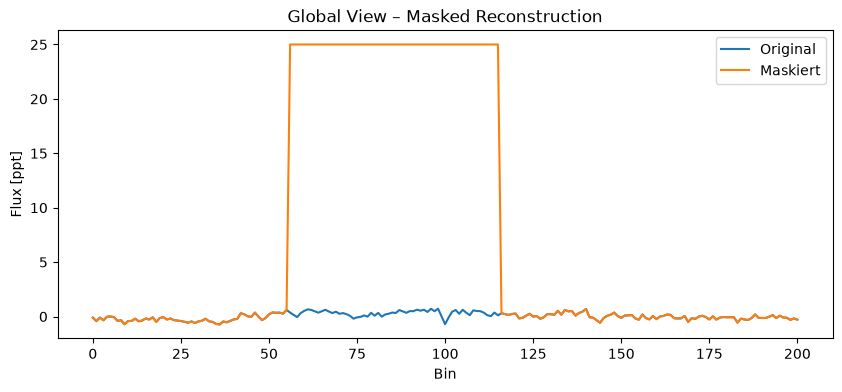

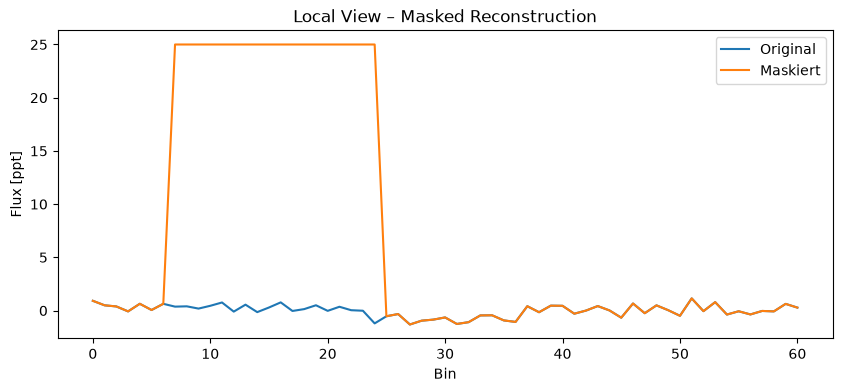

In [15]:
plt.figure(figsize=(10, 4))

plt.plot(
    sample_global.squeeze().numpy(),
    label="Original"
)

plt.plot(
    masked_global.squeeze().numpy(),
    label="Maskiert"
)

plt.title("Global View – Masked Reconstruction")
plt.xlabel("Bin")
plt.ylabel("Flux [ppt]")
plt.legend()

plt.show()


plt.figure(figsize=(10, 4))

plt.plot(
    sample_local.squeeze().numpy(),
    label="Original"
)

plt.plot(
    masked_local.squeeze().numpy(),
    label="Maskiert"
)

plt.title("Local View – Masked Reconstruction")
plt.xlabel("Bin")
plt.ylabel("Flux [ppt]")
plt.legend()

plt.show()

#### SSL-Dataloader erstellen

In [16]:
BATCH_SIZE = 32

ssl_train_loader = DataLoader(
    ssl_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(
    "Batches pro Epoche:",
    len(ssl_train_loader)
)

Batches pro Epoche: 50


#### Batch-Shapes prüfen

In [17]:
batch_global, batch_local = next(
    iter(ssl_train_loader)
)

print(
    "Global Batch:",
    batch_global.shape
)

print(
    "Local Batch:",
    batch_local.shape
)

print(
    "Global dtype:",
    batch_global.dtype
)

print(
    "Local dtype:",
    batch_local.dtype
)

Global Batch: torch.Size([32, 1, 201])
Local Batch: torch.Size([32, 1, 61])
Global dtype: torch.float32
Local dtype: torch.float32


#### Batchweise Maskierung

In [18]:
def mask_contiguous_batch(
    views,
    mask_ratio=MASK_RATIO,
    mask_value=MASK_VALUE
):
    masked_views = views.clone()

    batch_size = views.shape[0]
    n_bins = views.shape[-1]

    n_masked = round(
        n_bins * mask_ratio
    )

    mask = torch.zeros_like(
        views,
        dtype=torch.bool
    )

    for i in range(batch_size):
        start = torch.randint(
            0,
            n_bins - n_masked + 1,
            (1,)
        ).item()

        mask[
            i,
            :,
            start:start + n_masked
        ] = True

    masked_views[mask] = mask_value

    return masked_views, mask

#### Batch-Maskierung prüfen

In [19]:
masked_batch_global, batch_global_mask = (
    mask_contiguous_batch(
        batch_global
    )
)

masked_batch_local, batch_local_mask = (
    mask_contiguous_batch(
        batch_local
    )
)

global_mask_counts = (
    batch_global_mask
    .sum(dim=(1, 2))
)

local_mask_counts = (
    batch_local_mask
    .sum(dim=(1, 2))
)

print(
    "Global maskierte Bins pro Sample:",
    global_mask_counts.unique()
)

print(
    "Local maskierte Bins pro Sample:",
    local_mask_counts.unique()
)

print(
    "Global Maskenwert korrekt:",
    torch.all(
        masked_batch_global[
            batch_global_mask
        ] == MASK_VALUE
    ).item()
)

print(
    "Local Maskenwert korrekt:",
    torch.all(
        masked_batch_local[
            batch_local_mask
        ] == MASK_VALUE
    ).item()
)

Global maskierte Bins pro Sample: tensor([60])
Local maskierte Bins pro Sample: tensor([18])
Global Maskenwert korrekt: True
Local Maskenwert korrekt: True


### CNN-Encoder definieren

In [20]:
POOL_OUTPUT_SIZE = 8
ENCODER_CHANNELS = 64
ENCODED_FEATURES = (
    ENCODER_CHANNELS
    * POOL_OUTPUT_SIZE
)


class LightCurveEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.AdaptiveAvgPool1d(
                POOL_OUTPUT_SIZE
            )
        )

    def forward(self, x):
        x = self.features(x)

        return torch.flatten(
            x,
            start_dim=1
        )

#### SSL-Rekonstruktionsmodell definieren

In [21]:
class MaskedReconstructionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.global_encoder = LightCurveEncoder()
        self.local_encoder = LightCurveEncoder()

        self.global_head = nn.Linear(
            ENCODED_FEATURES,
            201
        )

        self.local_head = nn.Linear(
            ENCODED_FEATURES,
            61
        )

    def forward(
        self,
        global_view,
        local_view
    ):
        global_features = self.global_encoder(
            global_view
        )

        local_features = self.local_encoder(
            local_view
        )

        global_reconstruction = (
            self.global_head(
                global_features
            )
        )

        local_reconstruction = (
            self.local_head(
                local_features
            )
        )

        return (
            global_reconstruction,
            local_reconstruction
        )

#### Forward-Pass prüfen

In [22]:
ssl_model = MaskedReconstructionModel().to(
    DEVICE
)

masked_batch_global = (
    masked_batch_global.to(DEVICE)
)

masked_batch_local = (
    masked_batch_local.to(DEVICE)
)

with torch.no_grad():
    reconstructed_global, reconstructed_local = (
        ssl_model(
            masked_batch_global,
            masked_batch_local
        )
    )

print(
    "Global Reconstruction:",
    reconstructed_global.shape
)

print(
    "Local Reconstruction:",
    reconstructed_local.shape
)

Global Reconstruction: torch.Size([32, 201])
Local Reconstruction: torch.Size([32, 61])


#### Loss nur auf maskierten Positionen

In [23]:
def masked_mse_loss(
    reconstruction,
    target,
    mask
):
    target = target.squeeze(1)
    mask = mask.squeeze(1)

    squared_error = (
        reconstruction - target
    ) ** 2

    return squared_error[
        mask
    ].mean()

#### SSL-Trainingsparameter

In [25]:
SSL_LEARNING_RATE = 0.001

ssl_optimizer = torch.optim.Adam(
    ssl_model.parameters(),
    lr=SSL_LEARNING_RATE
)

#### Seeds

In [27]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

#### SSL-Trainingsdauer

In [28]:
SSL_MAX_EPOCHS = 150
SSL_PATIENCE = 20

print(
    "SSL Max Epochen:",
    SSL_MAX_EPOCHS
)

print(
    "SSL Patience:",
    SSL_PATIENCE
)

SSL Max Epochen: 150
SSL Patience: 20


#### SSL-Pretraining Funktion

In [29]:
def pretrain_ssl(seed):
    set_seed(seed)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)

    train_loader = DataLoader(
        ssl_train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=loader_generator
    )

    model = MaskedReconstructionModel().to(
        DEVICE
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=SSL_LEARNING_RATE
    )

    history = []

    best_loss = float("inf")
    best_epoch = 0
    best_state = None

    epochs_without_improvement = 0

    for epoch in range(
        1,
        SSL_MAX_EPOCHS + 1
    ):
        model.train()

        running_loss = 0.0
        n_samples = 0

        for global_view, local_view in train_loader:
            global_view = global_view.to(DEVICE)
            local_view = local_view.to(DEVICE)

            masked_global, global_mask = (
                mask_contiguous_batch(
                    global_view
                )
            )

            masked_local, local_mask = (
                mask_contiguous_batch(
                    local_view
                )
            )

            optimizer.zero_grad()

            (
                reconstruction_global,
                reconstruction_local
            ) = model(
                masked_global,
                masked_local
            )

            global_loss = masked_mse_loss(
                reconstruction_global,
                global_view,
                global_mask
            )

            local_loss = masked_mse_loss(
                reconstruction_local,
                local_view,
                local_mask
            )

            loss = (
                0.5 * global_loss
                + 0.5 * local_loss
            )

            loss.backward()
            optimizer.step()

            batch_size = global_view.shape[0]

            running_loss += (
                loss.item()
                * batch_size
            )

            n_samples += batch_size

        epoch_loss = (
            running_loss
            / n_samples
        )

        history.append(
            epoch_loss
        )

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_epoch = epoch

            best_state = {
                name: value
                .detach()
                .cpu()
                .clone()
                for name, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= SSL_PATIENCE
        ):
            break

    model.load_state_dict(
        best_state
    )

    return (
        model,
        history,
        best_epoch,
        best_loss
    )

In [30]:
ssl_models = {}
ssl_histories = {}
ssl_best_epochs = {}
ssl_best_losses = {}

for experiment_seed in EXPERIMENT_SEEDS:
    (
        model,
        history,
        best_epoch,
        best_loss
    ) = pretrain_ssl(
        experiment_seed
    )

    ssl_models[experiment_seed] = model
    ssl_histories[experiment_seed] = history
    ssl_best_epochs[experiment_seed] = best_epoch
    ssl_best_losses[experiment_seed] = best_loss

    print(
        f"Seed {experiment_seed}: "
        f"Beste Epoche "
        f"{best_epoch} | "
        f"{len(history)} "
        f"Epochen trainiert | "
        f"Bester Loss "
        f"{best_loss:.4f}"
    )

Seed 7: Beste Epoche 94 | 114 Epochen trainiert | Bester Loss 3.5315
Seed 21: Beste Epoche 133 | 150 Epochen trainiert | Bester Loss 3.1211
Seed 42: Beste Epoche 100 | 120 Epochen trainiert | Bester Loss 3.5164
Seed 84: Beste Epoche 106 | 126 Epochen trainiert | Bester Loss 3.5207
Seed 123: Beste Epoche 132 | 150 Epochen trainiert | Bester Loss 3.2869


#### SSL-Loss visuell

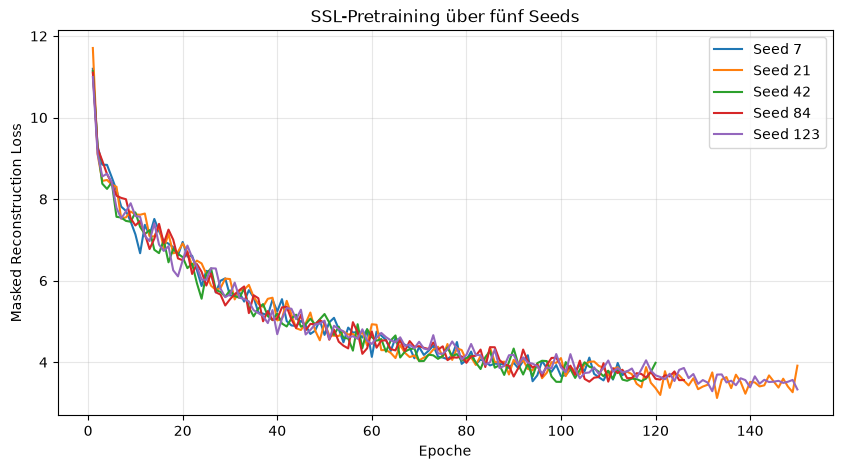

In [31]:
plt.figure(figsize=(10, 5))

for experiment_seed in EXPERIMENT_SEEDS:
    history = ssl_histories[
        experiment_seed
    ]

    plt.plot(
        range(1, len(history) + 1),
        history,
        label=f"Seed {experiment_seed}"
    )

plt.xlabel("Epoche")
plt.ylabel("Masked Reconstruction Loss")
plt.title("SSL-Pretraining über fünf Seeds")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Pretrained Encoder speichern

In [32]:
for experiment_seed in EXPERIMENT_SEEDS:
    model = ssl_models[
        experiment_seed
    ]

    save_path = (
        PRETRAINING_DIR
        / f"ssl_encoders_seed_{experiment_seed}.pt"
    )

    torch.save(
        {
            "global_encoder": (
                model.global_encoder.state_dict()
            ),
            "local_encoder": (
                model.local_encoder.state_dict()
            ),
            "best_epoch": (
                ssl_best_epochs[
                    experiment_seed
                ]
            ),
            "best_loss": (
                ssl_best_losses[
                    experiment_seed
                ]
            )
        },
        save_path
    )

    print(
        f"Gespeichert: {save_path.name}"
    )

Gespeichert: ssl_encoders_seed_7.pt
Gespeichert: ssl_encoders_seed_21.pt
Gespeichert: ssl_encoders_seed_42.pt
Gespeichert: ssl_encoders_seed_84.pt
Gespeichert: ssl_encoders_seed_123.pt


In [33]:
check_path = (
    PRETRAINING_DIR
    / "ssl_encoders_seed_42.pt"
)

checkpoint = torch.load(
    check_path,
    map_location="cpu",
    weights_only=True
)

check_global_encoder = LightCurveEncoder()
check_local_encoder = LightCurveEncoder()

check_global_encoder.load_state_dict(
    checkpoint["global_encoder"]
)

check_local_encoder.load_state_dict(
    checkpoint["local_encoder"]
)

print(
    "Beste Epoche:",
    checkpoint["best_epoch"]
)

print(
    "Bester Loss:",
    checkpoint["best_loss"]
)

print(
    "Global Encoder geladen:",
    len(checkpoint["global_encoder"])
)

print(
    "Local Encoder geladen:",
    len(checkpoint["local_encoder"])
)

Beste Epoche: 100
Bester Loss: 3.516431531212981
Global Encoder geladen: 4
Local Encoder geladen: 4


### Fine-Tuning - AstroNet-Klassifikator definieren

In [34]:
class AstroNetClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.global_encoder = (
            LightCurveEncoder()
        )

        self.local_encoder = (
            LightCurveEncoder()
        )

        self.classifier = nn.Sequential(
            nn.Linear(
                2 * ENCODED_FEATURES,
                128
            ),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(
                128,
                1
            )
        )

    def forward(
        self,
        global_view,
        local_view
    ):
        global_features = (
            self.global_encoder(
                global_view
            )
        )

        local_features = (
            self.local_encoder(
                local_view
            )
        )

        combined = torch.cat(
            [
                global_features,
                local_features
            ],
            dim=1
        )

        return self.classifier(
            combined
        ).squeeze(1)

#### Pretrained Encoder in Klassifikator laden

In [35]:
finetune_model = AstroNetClassifier()

checkpoint = torch.load(
    PRETRAINING_DIR
    / "ssl_encoders_seed_42.pt",
    map_location="cpu",
    weights_only=True
)

finetune_model.global_encoder.load_state_dict(
    checkpoint["global_encoder"]
)

finetune_model.local_encoder.load_state_dict(
    checkpoint["local_encoder"]
)

print(
    "Global Encoder geladen:",
    len(checkpoint["global_encoder"])
)

print(
    "Local Encoder geladen:",
    len(checkpoint["local_encoder"])
)

print(
    "Parameter gesamt:",
    sum(
        p.numel()
        for p in finetune_model.parameters()
    )
)

Global Encoder geladen: 4
Local Encoder geladen: 4
Parameter gesamt: 152321


#### Dataset für Fine-Tuning definieren

In [36]:
class LightCurveDataset(Dataset):
    def __init__(
        self,
        X_global,
        X_local,
        y,
        indices
    ):
        self.X_global = X_global
        self.X_local = X_local
        self.y = y
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        sample_index = self.indices[index]

        global_view = torch.tensor(
            self.X_global[sample_index],
            dtype=torch.float32
        ).unsqueeze(0)

        local_view = torch.tensor(
            self.X_local[sample_index],
            dtype=torch.float32
        ).unsqueeze(0)

        label = torch.tensor(
            self.y[sample_index],
            dtype=torch.float32
        )

        return (
            global_view,
            local_view,
            label
        )

In [37]:
validation_indices = np.flatnonzero(
    metadata["split"].to_numpy()
    == "validation"
)

finetune_datasets = {
    100: LightCurveDataset(
        X_global_model,
        X_local_model,
        y,
        train_indices_100
    ),
    50: LightCurveDataset(
        X_global_model,
        X_local_model,
        y,
        train_indices_50
    ),
    25: LightCurveDataset(
        X_global_model,
        X_local_model,
        y,
        train_indices_25
    ),
    10: LightCurveDataset(
        X_global_model,
        X_local_model,
        y,
        train_indices_10
    )
}

validation_dataset = LightCurveDataset(
    X_global_model,
    X_local_model,
    y,
    validation_indices
)

for percentage, dataset in finetune_datasets.items():
    print(
        f"{percentage} % Training:",
        len(dataset)
    )

print(
    "Validation:",
    len(validation_dataset)
)

100 % Training: 1596
50 % Training: 798
25 % Training: 399
10 % Training: 159
Validation: 342


In [38]:
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    n_samples = 0

    for (
        global_view,
        local_view,
        labels
    ) in data_loader:
        global_view = global_view.to(device)
        local_view = local_view.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(
            global_view,
            local_view
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()
        optimizer.step()

        batch_size = labels.shape[0]

        running_loss += (
            loss.item()
            * batch_size
        )

        n_samples += batch_size

    return running_loss / n_samples

#### Validation-Loss berechnen

Misst, wie gut das aktuelle Modell auf dem 342 Validation-Samples abschneidet. 

In [39]:
def evaluate_loss(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0

    with torch.no_grad():
        for (
            global_view,
            local_view,
            labels
        ) in data_loader:

            global_view = global_view.to(device)
            local_view = local_view.to(device)
            labels = labels.to(device)

            outputs = model(
                global_view,
                local_view
            )

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
                * labels.size(0)
            )

    epoch_loss = (
        running_loss
        / len(data_loader.dataset)
    )

    return epoch_loss

#### Fine-Tuning

Maximal 100 Epochen, um mit Baseline vergleichen zu können 

In [40]:
def train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    max_epochs=100,
    patience=20
):
    train_losses = []
    validation_losses = []

    best_validation_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        validation_loss = evaluate_loss(
            model,
            validation_loader,
            criterion,
            device
        )

        train_losses.append(train_loss)
        validation_losses.append(
            validation_loss
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = (
                validation_loss
            )

            best_state = {
                key: value.detach().cpu().clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= patience
        ):
            break

    model.load_state_dict(best_state)

    return (
        model,
        train_losses,
        validation_losses
    )

#### Fine Tuning Parameter

In [41]:
LEARNING_RATE = 0.001
MAX_EPOCHS = 100
PATIENCE = 20

criterion = nn.BCEWithLogitsLoss()

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Learning Rate:", LEARNING_RATE)
print("Maximale Epochen:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Validation-Batches:", len(validation_loader))

Learning Rate: 0.001
Maximale Epochen: 100
Patience: 20
Validation-Batches: 11


#### SSL-vortrainiertn Klassifikator erzeugen

In [42]:
def create_pretrained_classifier(seed):
    set_seed(seed)

    model = AstroNetClassifier()

    checkpoint = torch.load(
        PRETRAINING_DIR
        / f"ssl_encoders_seed_{seed}.pt",
        map_location="cpu",
        weights_only=True
    )

    model.global_encoder.load_state_dict(
        checkpoint["global_encoder"]
    )

    model.local_encoder.load_state_dict(
        checkpoint["local_encoder"]
    )

    return model.to(DEVICE)

### Fine-Tuning vom SSL-Modell

In [43]:
def finetune_ssl_model(
    label_percentage,
    seed
):
    train_dataset = finetune_datasets[
        label_percentage
    ]

    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=loader_generator
    )

    model = create_pretrained_classifier(
        seed
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    (
        model,
        train_losses,
        validation_losses
    ) = train_model(
        model,
        train_loader,
        validation_loader,
        criterion,
        optimizer,
        DEVICE,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE
    )

    return (
        model,
        train_losses,
        validation_losses
    )

In [ ]:
check_model, check_train_losses, check_validation_losses = (
    finetune_ssl_model(
        label_percentage=100,
        seed=42
    )
)

print(
    "Beste Epoche:",
    np.argmin(check_validation_losses) + 1
)

print(
    "Trainierte Epochen:",
    len(check_train_losses)
)

print(
    "Bester Validation Loss:",
    min(check_validation_losses)
)

Beste Epoche: 6
Trainierte Epochen: 26
Bester Validation Loss: 0.5890970167360807


In [45]:
finetune_models = {}
finetune_histories = {}

for label_percentage in [100, 50, 25, 10]:
    finetune_models[label_percentage] = {}
    finetune_histories[label_percentage] = {}

    for experiment_seed in EXPERIMENT_SEEDS:
        (
            current_model,
            current_train_losses,
            current_validation_losses
        ) = finetune_ssl_model(
            label_percentage,
            experiment_seed
        )

        finetune_models[
            label_percentage
        ][experiment_seed] = current_model

        finetune_histories[
            label_percentage
        ][experiment_seed] = {
            "train_loss": current_train_losses,
            "validation_loss": (
                current_validation_losses
            )
        }

        print(
            f"{label_percentage} % | "
            f"Seed {experiment_seed}: "
            f"beste Epoche "
            f"{np.argmin(current_validation_losses) + 1}, "
            f"{len(current_train_losses)} "
            f"Epochen trainiert"
        )

100 % | Seed 7: beste Epoche 7, 27 Epochen trainiert
100 % | Seed 21: beste Epoche 4, 24 Epochen trainiert
100 % | Seed 42: beste Epoche 6, 26 Epochen trainiert
100 % | Seed 84: beste Epoche 5, 25 Epochen trainiert
100 % | Seed 123: beste Epoche 4, 24 Epochen trainiert
50 % | Seed 7: beste Epoche 8, 28 Epochen trainiert
50 % | Seed 21: beste Epoche 7, 27 Epochen trainiert
50 % | Seed 42: beste Epoche 11, 31 Epochen trainiert
50 % | Seed 84: beste Epoche 8, 28 Epochen trainiert
50 % | Seed 123: beste Epoche 6, 26 Epochen trainiert
25 % | Seed 7: beste Epoche 3, 23 Epochen trainiert
25 % | Seed 21: beste Epoche 4, 24 Epochen trainiert
25 % | Seed 42: beste Epoche 2, 22 Epochen trainiert
25 % | Seed 84: beste Epoche 5, 25 Epochen trainiert
25 % | Seed 123: beste Epoche 3, 23 Epochen trainiert
10 % | Seed 7: beste Epoche 4, 24 Epochen trainiert
10 % | Seed 21: beste Epoche 5, 25 Epochen trainiert
10 % | Seed 42: beste Epoche 3, 23 Epochen trainiert
10 % | Seed 84: beste Epoche 3, 23 Epoche

### Metriken

In [46]:
THRESHOLD = 0.5
PRIMARY_METRIC = "roc_auc"

METRIC_COLUMNS = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision"
]


def calculate_metrics(
    labels,
    probabilities
):
    y_true = labels.numpy().astype(int)
    y_prob = probabilities.numpy()

    y_pred = (
        y_prob >= THRESHOLD
    ).astype(int)

    return {
        "accuracy": float(
            np.mean(y_pred == y_true)
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_prob
        ),
        "average_precision": (
            average_precision_score(
                y_true,
                y_prob
            )
        )
    }

In [47]:
def predict_probabilities(
    model,
    data_loader,
    device
):
    all_probabilities = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for (
            global_view,
            local_view,
            labels
        ) in data_loader:

            global_view = global_view.to(device)
            local_view = local_view.to(device)

            logits = model(
                global_view,
                local_view
            )

            probabilities = torch.sigmoid(
                logits
            )

            all_probabilities.append(
                probabilities.cpu()
            )

            all_labels.append(
                labels.cpu()
            )

    return (
        torch.cat(all_probabilities),
        torch.cat(all_labels)
    )

#### Validation-Metriken für SSL-Modelle

In [48]:
ssl_validation_rows = []

for label_percentage in [100, 50, 25, 10]:
    for experiment_seed in EXPERIMENT_SEEDS:
        model = finetune_models[
            label_percentage
        ][experiment_seed]

        probabilities, labels = (
            predict_probabilities(
                model,
                validation_loader,
                DEVICE
            )
        )

        ssl_validation_rows.append(
            {
                "label_percentage": (
                    label_percentage
                ),
                "seed": experiment_seed,
                **calculate_metrics(
                    labels,
                    probabilities
                )
            }
        )

ssl_validation_results = pd.DataFrame(
    ssl_validation_rows
)

for label_percentage in [100, 50, 25, 10]:
    current_results = ssl_validation_results[
        ssl_validation_results[
            "label_percentage"
        ] == label_percentage
    ]

    mean_roc_auc = (
        current_results["roc_auc"].mean()
    )

    std_roc_auc = (
        current_results["roc_auc"].std()
    )

    print(
        f"{label_percentage} %: "
        f"ROC-AUC "
        f"{mean_roc_auc:.4f} ± "
        f"{std_roc_auc:.4f}"
    )

100 %: ROC-AUC 0.7996 ± 0.0017
50 %: ROC-AUC 0.7927 ± 0.0154
25 %: ROC-AUC 0.7359 ± 0.0130
10 %: ROC-AUC 0.7147 ± 0.0109


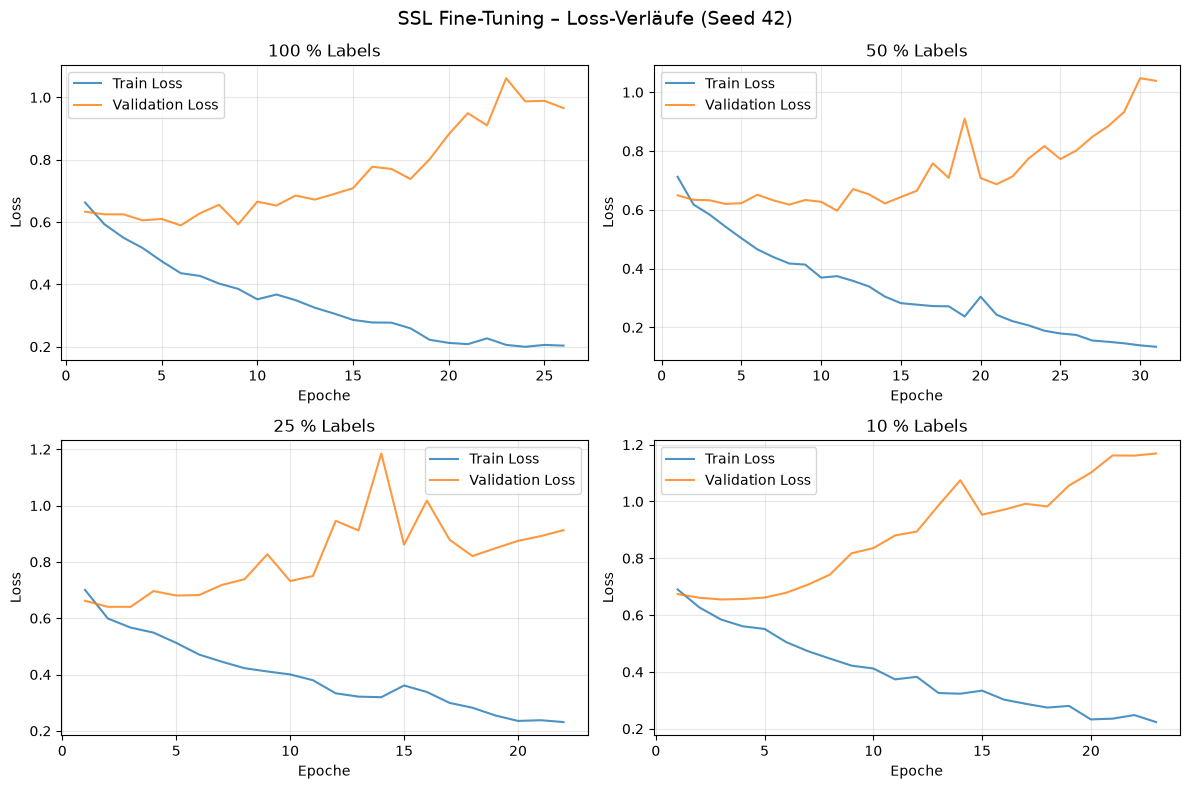

In [49]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.flatten()

for ax, label_percentage in zip(
    axes,
    [100, 50, 25, 10]
):
    history = finetune_histories[
        label_percentage
    ][SEED]

    train_losses = history[
        "train_loss"
    ]

    validation_losses = history[
        "validation_loss"
    ]

    epochs = range(
        1,
        len(train_losses) + 1
    )

    ax.plot(
        epochs,
        train_losses,
        label="Train Loss",
        alpha=0.8
    )

    ax.plot(
        epochs,
        validation_losses,
        label="Validation Loss",
        alpha=0.8
    )

    ax.set_title(
        f"{label_percentage} % Labels"
    )

    ax.set_xlabel("Epoche")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle(
    "SSL Fine-Tuning – Loss-Verläufe (Seed 42)",
    fontsize=14
)

plt.tight_layout()
plt.show()

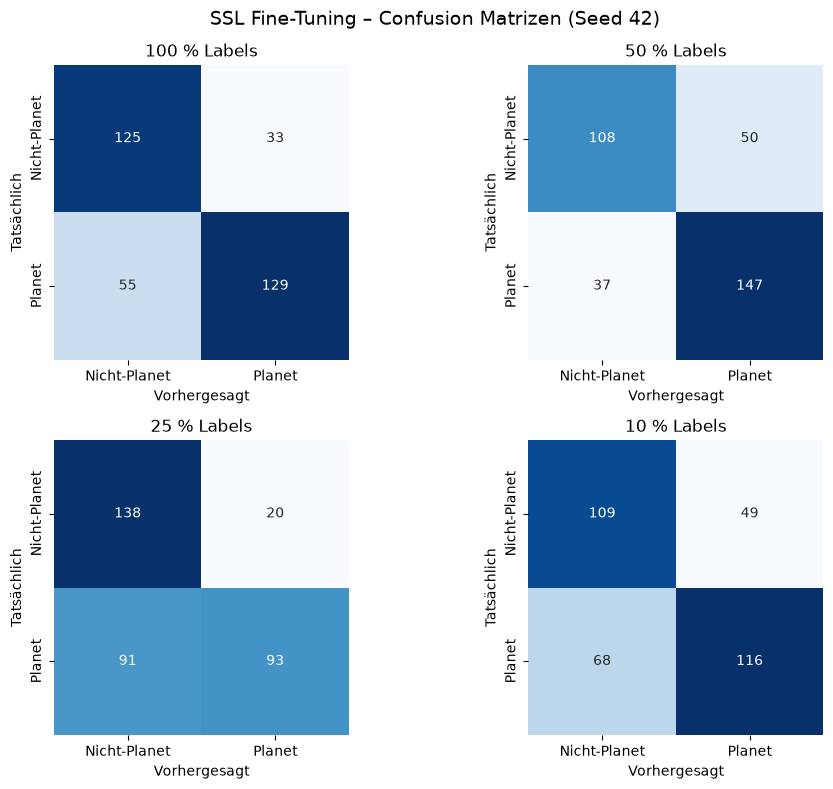

In [50]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 8)
)

axes = axes.flatten()

for ax, label_percentage in zip(
    axes,
    [100, 50, 25, 10]
):
    model = finetune_models[
        label_percentage
    ][SEED]

    probabilities, labels = (
        predict_probabilities(
            model,
            validation_loader,
            DEVICE
        )
    )

    y_true = labels.numpy().astype(int)
    y_prob = probabilities.numpy()

    y_pred = (
        y_prob >= THRESHOLD
    ).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        ax=ax,
        xticklabels=[
            "Nicht-Planet",
            "Planet"
        ],
        yticklabels=[
            "Nicht-Planet",
            "Planet"
        ]
    )

    ax.set_title(
        f"{label_percentage} % Labels"
    )

    ax.set_xlabel("Vorhergesagt")
    ax.set_ylabel("Tatsächlich")

fig.suptitle(
    "SSL Fine-Tuning – Confusion Matrizen (Seed 42)",
    fontsize=14
)

plt.tight_layout()
plt.show()

#### Alles fine-getunten Modell speichern

In [51]:
FINETUNING_DIR = (
    SSL_RESULTS_DIR
    / "finetuning"
)

FINETUNING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for label_percentage in [100, 50, 25, 10]:
    for experiment_seed in EXPERIMENT_SEEDS:
        model = finetune_models[
            label_percentage
        ][experiment_seed]

        save_path = (
            FINETUNING_DIR
            / (
                f"ssl_finetuned_"
                f"{label_percentage}_"
                f"seed_{experiment_seed}.pt"
            )
        )

        torch.save(
            model.state_dict(),
            save_path
        )

print(
    "Fine-Tuning-Modelle gespeichert:",
    20
)

Fine-Tuning-Modelle gespeichert: 20


In [52]:
history_arrays = {}

for label_percentage in [100, 50, 25, 10]:
    for experiment_seed in EXPERIMENT_SEEDS:
        history = finetune_histories[
            label_percentage
        ][experiment_seed]

        history_arrays[
            f"train_{label_percentage}_seed_{experiment_seed}"
        ] = np.array(
            history["train_loss"]
        )

        history_arrays[
            f"validation_{label_percentage}_seed_{experiment_seed}"
        ] = np.array(
            history["validation_loss"]
        )

np.savez_compressed(
    FINETUNING_DIR
    / "finetuning_histories.npz",
    **history_arrays
)

ssl_validation_results.to_csv(
    FINETUNING_DIR
    / "ssl_validation_results.csv",
    index=False
)

print("Fine-Tuning-Historien und Validation-Ergebnisse gespeichert.")

Fine-Tuning-Historien und Validation-Ergebnisse gespeichert.


#### SSL-Validation Zusammenfassung

In [53]:
summary_rows = []

for label_percentage in [100, 50, 25, 10]:
    current_results = ssl_validation_results[
        ssl_validation_results[
            "label_percentage"
        ] == label_percentage
    ]

    row = {
        "labels": label_percentage
    }

    for metric in METRIC_COLUMNS:
        row[f"{metric}_mean"] = (
            current_results[metric].mean()
        )

        row[f"{metric}_std"] = (
            current_results[metric].std()
        )

    summary_rows.append(row)

ssl_validation_summary = pd.DataFrame(
    summary_rows
)

display(
    ssl_validation_summary.style.format(
        precision=4
    )
)

,labels,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,100,0.7409,0.0177,0.7635,0.0400,0.7576,0.0426,0.7588,0.0106,0.7996,0.0017,0.7913,0.0082
1,50,0.7298,0.0127,0.7525,0.0154,0.7435,0.0497,0.7469,0.0204,0.7927,0.0154,0.7794,0.0194
2,25,0.6860,0.0259,0.7441,0.0467,0.6446,0.0946,0.6855,0.0463,0.7359,0.0130,0.7230,0.0060
3,10,0.6550,0.0142,0.7240,0.0162,0.5804,0.0379,0.6437,0.0229,0.7147,0.0109,0.6977,0.0179


In [54]:
SSL_VALIDATION_SUMMARY_FILE = (
    FINETUNING_DIR
    / "ssl_validation_summary.csv"
)

ssl_validation_summary.to_csv(
    SSL_VALIDATION_SUMMARY_FILE,
    index=False
)

print(
    "SSL-Validation-Zusammenfassung gespeichert:",
    SSL_VALIDATION_SUMMARY_FILE
)

SSL-Validation-Zusammenfassung gespeichert: c:\Users\User\Documents\VanessaExoplanets\Exoplanets\results\ssl\finetuning\ssl_validation_summary.csv


## Ergebnis

In diesem Notebook wurde ein Self-Supervised-Learning-Verfahren für die
vorverarbeiteten TESS-Lichtkurven umgesetzt.

#### Pretraining

Für das Pretraining wurden ausschließlich Samples des Trainingssplits verwendet.
Die vorhandenen Klassenlabels wurden dabei nicht genutzt.

Aus Global View und Local View wurden jeweils zusammenhängende Bereiche maskiert.
Das Modell erhielt die maskierten Lichtkurven als Eingabe und wurde darauf
trainiert, die ursprünglichen Werte in den maskierten Bereichen zu rekonstruieren.

Für das SSL-Pretraining wurden die fünf Seeds 7, 21, 42, 84 und 123 verwendet.

Die jeweils besten Encoder wurden gespeichert und anschließend für die
binäre Klassifikation weiterverwendet.

#### Fine-Tuning

Die vortrainierten Encoder wurden in dieselbe AstroNet-artige
Klassifikationsarchitektur übernommen, die bereits für die supervised Baseline
verwendet wurde.

Das Fine-Tuning wurde mit den zuvor festgelegten Trainings-Subsets (100%, 50%, 25% und 10% Trainingslabels) durchgeführt.

Für jede Labelmenge wurden erneut dieselben fünf Seeds verwendet.
Early Stopping erfolgte anhand des Validation Loss mit einer Patience von
20 Epochen.

Die Encoder wurden während des Fine-Tunings nicht eingefroren, sondern gemeinsam
mit dem Klassifikationskopf weiter optimiert.

#### Validation

Die Modelle wurden ausschließlich auf dem Validation-Split ausgewertet.
ROC-AUC dient als primäre Vergleichsmetrik. Zusätzlich wurden Accuracy,
Precision, Recall, F1-Score und Average Precision berechnet.

Die Ergebnisse wurden über die fünf Seeds als Mittelwert und
Standardabweichung zusammengefasst.

Der Test-Split wurde in diesem Notebook nicht verwendet.

Für die weitere Auswertung wurden folgenden Daten gespeichert:

- die SSL-vortrainierten Encoder
- die 20 fine-getunten Klassifikationsmodelle
- die Fine-Tuning-Loss-Historien
- die Validation-Ergebnisse der einzelnen Läufe
- die zusammengefassten SSL-Validation-Ergebnisse

Die finale Evaluation auf dem nicht angerührten Testdatensatz sowie der direkte
Vergleich zwischen supervised Baseline und SSL-Modellen erfolgt in `06_final_evaluation.ipynb`.